# Assignment 4: CNNs

- **Name**: Sadbhav Adhikari
- **Roll number**: ACE079BCT054

This assignment looks into the concept of convolutional neural networks (CNNs), and compares how normal neural networks compare to CNNs in classification tasks. In this specific case, we will be testing a normal neural network against two different CNNs:

- AlexNet, a breakthrough CNN developed in 2012 which was the first of its kind to be able to perform classification large-scale.
- TinyVGG, a newer CNN which focuses on efficiency.


Firstly, import torch and manually seed it.

In [ ]:
import torch

torch.manual_seed(42)

Create a transform to convert a datset to tensors, then normalize all the values for easier training.

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

Next, we grab the datasets, for both training and testing.

In this case, we will be using the CIFAR-10 dataset, which is a collection of 60,000 32x32 images, each classifiable into one of 10 categories. This dataset is among the most commonly used for training computer vision algorithms.

In [ ]:
import torchvision

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [05:28<00:00, 520kB/s] 


We will now create a train and test loader so that training is done in batches of 64 instead of training on all 60,000 images at once which would be extremely heavy on the computer.

In [ ]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

Visualize the data in the set to see what we're working with.

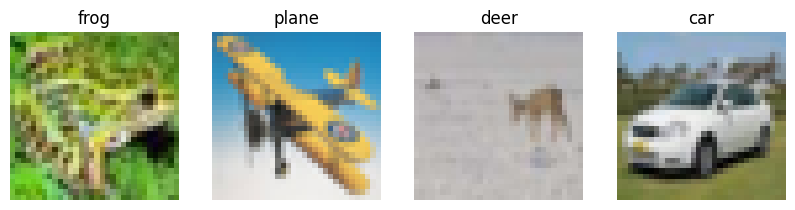

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i] / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(classes[labels[i]])
    plt.axis('off')

Make the code device-agnostic.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

We will use cross-entropy loss for the loss function.

Cross-entropy loss is a type of loss function which is specialized for use in classification problems. It measures the distance between a model's prediction and the correct classification.

For multi-class classification, the formula for cross-entropy loss can be given by

$$
CE = - \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} \left( y_{i,j} \log (p_{i,j}) \right)
$$

Where

- $N$ is the number of samples,
- $C$ is the number of classes,
- $y_{i,j}$ is 1 if class $j$ is correct for sample $i$, 0 otherwise.
- $p_{i,j}$ is the predicted probability by the model of sample $i$ being in class $j$.

Cross-entropy loss is especially useful because it assigns heavy penalties to answers that are confident but incorrect.

In [ ]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

Create the train & test function. We will be using the Adam optimizer, currently with a learning rate of `0.001`, and training for ten epochs.

In [ ]:
def train_and_test(model, epochs=10, learning_rate=0.001):
  model.to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  train_losses = []
  test_losses = []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()

      outputs = model(inputs)
      loss = loss_fn(outputs, labels)

      loss.backward()
      optimizer.step()

      running_loss += loss.item()

      _, predicted = torch.max(outputs, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)

            loss = loss_fn(outputs, labels)
            test_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_running_loss / len(testloader)
    test_acc = 100 * test_correct / test_total
    test_losses.append(test_loss)

    print(f"epoch {epoch+1} | train acc: {train_acc:.2f} | train loss: {train_loss:.4f} | test acc: {test_acc:.2f} | test loss: {test_loss:.4f}")

  return train_losses, test_losses

For comparison of the model sizes create a function to count the number of parameters.

In [ ]:
def count_params(model):
  return sum(p.numel() for p in model.parameters())

## Plain NN



The first model will simply be a plain neural network with the images (32x32 with 3 color channels) flattened for the initial layer, two hidden layers with 512 and 256 neurons each, and the final layer having the 10 class outputs. We use $\mathrm{ReLU}$ as the activation function.

In [ ]:
import torch.nn.functional as F

class NN(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(32*32*3, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10)

  def forward(self, x):
    x = x.view(-1, 32*32*3)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
import time

model_nn = NN()
print("number of parameters: ", count_params(model_nn))
print()

start = time.time()
losses_nn = train_and_test(model_nn)
end = time.time()
print("train time: ", end - start, "seconds")

number of parameters:  1707274

epoch 1 | train acc: 42.11 | train loss: 1.6352 | test acc: 47.37 | test loss: 1.4893
epoch 2 | train acc: 49.27 | train loss: 1.4328 | test acc: 50.60 | test loss: 1.4181
epoch 3 | train acc: 53.53 | train loss: 1.3188 | test acc: 50.75 | test loss: 1.4052
epoch 4 | train acc: 56.64 | train loss: 1.2239 | test acc: 52.33 | test loss: 1.3658
epoch 5 | train acc: 59.73 | train loss: 1.1397 | test acc: 52.85 | test loss: 1.3743
epoch 6 | train acc: 62.40 | train loss: 1.0654 | test acc: 52.81 | test loss: 1.3984
epoch 7 | train acc: 64.74 | train loss: 0.9890 | test acc: 52.46 | test loss: 1.4640
epoch 8 | train acc: 67.37 | train loss: 0.9152 | test acc: 53.14 | test loss: 1.4838
epoch 9 | train acc: 69.91 | train loss: 0.8461 | test acc: 53.35 | test loss: 1.5354
epoch 10 | train acc: 72.23 | train loss: 0.7788 | test acc: 52.66 | test loss: 1.5886
train time:  152.37018275260925 seconds


We can see from the training results that the training accuracy is not particularly great at 72%, and the test accuracy is far worse at around 53%. This is a clear case of **overfitting**, that is, the model fails to generalize to new data despite working well on the data it has seen.

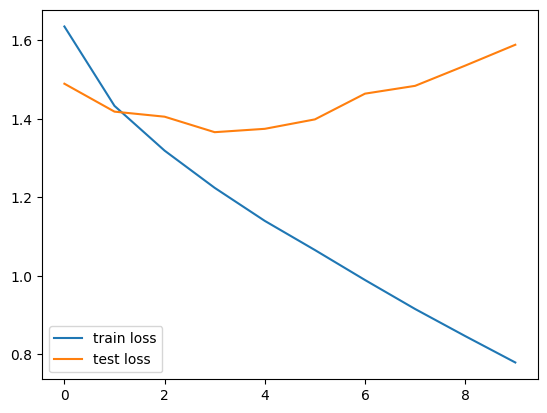

In [ ]:
plt.plot(losses_nn[0], label="train loss")
plt.plot(losses_nn[1], label="test loss")
plt.legend()
plt.show()

Plotting makes it clearer; the test losses have not decreased but rather shown instability.

## AlexNet

AlexNet uses a significantly different approach. Instead of using a fully connected network, it has convolutional filters as layers, where each filter only sees a small portion of the full image. This allows the network to keep the structure of the image, unlike the NN where the flattening of the entire image causes structural data to collapse.

In [ ]:
class AlexNetCIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model_alex = AlexNetCIFAR()
print("number of parameters: ", count_params(model_alex))
print()

start = time.time()
losses_alex = train_and_test(model_alex)
end = time.time()
print("train time: ", end - start, "seconds")

number of parameters:  35855178

epoch 1 | train acc: 41.54 | train loss: 1.5693 | test acc: 55.11 | test loss: 1.2595
epoch 2 | train acc: 59.42 | train loss: 1.1391 | test acc: 64.05 | test loss: 1.0289
epoch 3 | train acc: 66.86 | train loss: 0.9475 | test acc: 68.97 | test loss: 0.9019
epoch 4 | train acc: 70.58 | train loss: 0.8415 | test acc: 71.00 | test loss: 0.8389
epoch 5 | train acc: 74.11 | train loss: 0.7430 | test acc: 69.99 | test loss: 0.8886
epoch 6 | train acc: 76.58 | train loss: 0.6733 | test acc: 72.76 | test loss: 0.8043
epoch 7 | train acc: 78.76 | train loss: 0.6155 | test acc: 73.20 | test loss: 0.8097
epoch 8 | train acc: 80.76 | train loss: 0.5567 | test acc: 74.45 | test loss: 0.7855
epoch 9 | train acc: 81.66 | train loss: 0.5225 | test acc: 74.87 | test loss: 0.7681
epoch 10 | train acc: 83.58 | train loss: 0.4735 | test acc: 74.71 | test loss: 0.8006
train time:  324.16303515434265 seconds


The difference in approach causes a clear change. While the model is significantly larger in size at about 21 times larger than the plain NN, and thus takes longer to train, it does provide better results with a higher train accuracy of around 84%. More importantly, it provides a significantly better test accuracy around 75%, showing a higher capability in generalization to new data.

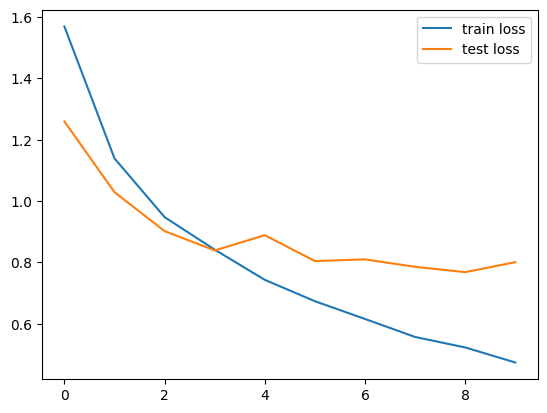

In [ ]:
plt.plot(losses_alex[0], label="train loss")
plt.plot(losses_alex[1], label="test loss")
plt.legend()
plt.show()

The plot reflects the previously retrieved info; both the train and test losses are decreasing, and while the test loss is still a little unstable, the level of instability is far lower than in the case of the plain NN.

## TinyVGG

While AlexNet provides much better performance, it also increases the complexity of the model by a large amount. As seen in the previous cells, AlexNet took over double the time to train compared to the plain NN, due to the 35.8 million parameters it contains in comparison to the plain NN's 1.7 million. This is a problem for cases where we have poorer hardware.

TinyVGG attempts to fix this issue. The main reason for the slow speed of AlexNet was the presence of large fully connected layers at the end, and the fact that it was designed for larger images; TinyVGG reduces the full connections and keeps a consistent structure of more convolutional layers instead. This should theoretically make it faster and more efficient.

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [ ]:
model_tinyvgg = TinyVGG()
print("number of parameters: ", count_params(model_tinyvgg))
print()

start = time.time()
losses_tinyvgg = train_and_test(model_tinyvgg)
end = time.time()
print("train time: ", end - start, "seconds")

number of parameters:  591274

epoch 1 | train acc: 49.90 | train loss: 1.3882 | test acc: 60.76 | test loss: 1.0945
epoch 2 | train acc: 66.61 | train loss: 0.9394 | test acc: 68.04 | test loss: 0.8978
epoch 3 | train acc: 73.07 | train loss: 0.7616 | test acc: 69.87 | test loss: 0.8475
epoch 4 | train acc: 77.74 | train loss: 0.6286 | test acc: 73.95 | test loss: 0.7674
epoch 5 | train acc: 81.30 | train loss: 0.5260 | test acc: 71.89 | test loss: 0.8523
epoch 6 | train acc: 84.47 | train loss: 0.4380 | test acc: 74.69 | test loss: 0.7990
epoch 7 | train acc: 87.23 | train loss: 0.3593 | test acc: 75.99 | test loss: 0.7719
epoch 8 | train acc: 89.89 | train loss: 0.2868 | test acc: 74.27 | test loss: 0.9300
epoch 9 | train acc: 91.89 | train loss: 0.2290 | test acc: 74.39 | test loss: 1.0263
epoch 10 | train acc: 93.61 | train loss: 0.1833 | test acc: 75.27 | test loss: 1.1067
train time:  209.07688760757446 seconds


The results paint a clear picture. The train accuracy is very high at around 94%, beating out AlexNet. In addition, it also has a test accuracy around 75%, similar to AlexNet.

Most significantly though, it trains at a much higher speed; 10 epochs are done in just 209 seconds here, compared to AlexNet which took about 324 seconds, over 1.5x the time. This is possible due to its significantly smaller size; it only uses 591,274 parameters compared to the 35.8 million used by AlexNet, and even less than the 1.7 million used by the plain neural network.

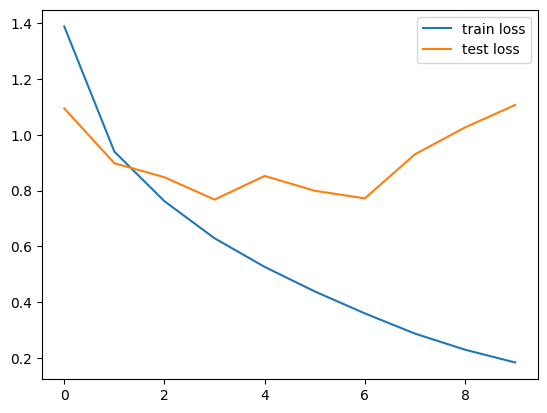

In [ ]:
plt.plot(losses_tinyvgg[0], label="train loss")
plt.plot(losses_tinyvgg[1], label="test loss")
plt.legend()
plt.show()

The test losses are quite unstable in TinyVGG but the overall performance is still fairly good.

## Discussion

In this assignment, three different neural network models were tested for classification of the CIFAR-10 dataset, to gauge how each of them perform at the task and to find out which performs best. The three models used were a plain neural network, the revolutionary AlexNet, and the efficient TinyVGG.

The plain neural network works by flattening the entire image and color channels, forming a 3,072 neuron input layer. Because of the flattening, the network loses all spatial information about the pixel, and therefore performs quite poorly, especially on unseen data.

AlexNet improves on this approach. It uses several hierarchical convolutional layers to separate various features of the image, therefore being able to actually "understand" the image and what is present in it. This is reflected by its performance, achieving a 84% accuracy on trained data, and still performing well at classifying unseen data with a 75% accuracy rate. However, one drawback of AlexNet is its huge size due to its large number of parameters, causing it to take very long to train.

TinyVGG fixes the issue with AlexNet by reducing the size of the fully connected layers to reduce the size. Additionally, it focuses more on the convolutional layers and adds more $\mathrm{ReLU}$ layers for higher non-linearity and thus more expressiveness. This shows in the results, with TinyVGG achieving a 94% accuracy in the trained data, much better than AlexNet; and a 75% test accuracy, around the same as AlexNet but at a much smaller size.

## Conclusion

Thus, in this assignment, we learnt about CNNs and how they can make specifically image classification tasks much more efficient in comparison to plain neural networks.